# Tutorial

We start by importing Matplotlib and NumPy.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

Let's set the seed of the random number generator for reproducibility.

In [2]:
np.random.seed(42)

And the relevant ``exogaia`` classes.

In [3]:
from exogaia.data import EpochAstrometry
from exogaia.leastsq import LeastSquares
from exogaia.models import BinaryModel
from exogaia.results import FitResults
from exogaia.sampler import MCMCSampler, NestedSampler

Workaround solutions for the Gaia Archive issues following the infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


## Gaia epoch astrometry

The ``EpochAstrometry`` class is used for storing Gaia epoch astrometry. In the future, we can either retrieve the data from the archive. For now, we can simulate epoch astrometry for Gaia DR4 or DR5. To do so, we can either set the stellar parameters manually or retrieving parameters from DR3. In this first example, we will simulate DR4 epoch astrometry for the star AF Lep.

In [4]:
source_id = 6199395656645840384  # HD 135344 A

In [5]:
primary_mass = (2.2, 0.1)  # (Msun)

In [6]:
eepoch_astrom = EpochAstrometry(primary_mass=primary_mass, gaia_release='DR4')


----------------
Epoch astrometry
----------------

Gaia release: DR4
Reference epoch: 2017.5

Primary mass (Msun): 2.20 +/- 0.10


Now we query the relevant stellar parameters from Gaia DR3. The parameters will be stored as attributes of the `EpochAstrometry` object, but also returned as list for convenience.

In [7]:
params = epoch_astrom.query_source(source_id=source_id, gaia_release='DR3')


---------------
Querying source
---------------

Gaia release: DR3
Source ID: 6199395656645840384

INFO: Query finished. [astroquery.utils.tap.core]

RA: 228.954 deg +/- 0.038 mas
Dec: -37.149 deg +/- 0.026 mas
Parallax: 7.411 +/- 0.040 mas
Proper motion in RA: -18.738 +/- 0.051 mas/yr
Proper motion in Dec: -24.008 +/- 0.035 mas/yr
G-band magnitude: 7.748


## Single star

We start with simulating epoch astrometry for a single star. As example, we use the retrieved stellar parameters of HD 135344 A.

In [8]:
model_param = epoch_astrom.simulate_data(ra=None, dec=None, parallax=None, pmra=None, pmdec=None, phot_g_mean_mag=None)


-------------
Simulate data
-------------

System type: single

AL scan uncertainty (per CCD) = 193.14 uas
AL scan uncertainty (per transit) = 68.29 uas

Stellar parameters:
   - RA (deg) = 228.95
   - Dec (deg) = -37.15
   - Parallax (mas) = 7.41
   - Proper motion in RA (mas/yr) = -18.74
   - Proper motion in Dec (mas/yr) = -24.01
   - G-band magnitude = 7.75


Now we run a linear least-squares fit to determine the best-fit parameters and uncertainties of the stellar track.

In [9]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)


--------------------------
Single star (5-parameters)
--------------------------

Reduced chi^2 = 1.325
RUWE = 1.151
Inflation factor = 1.155

Best-fit parameters:
   - RA = 228.970 deg +/- 0.016 mas
   - Dec = -37.140 deg +/- 0.011 mas
   - Parallax = 7.424 +/- 0.019 mas
   - mu in RA = -18.760 +/- 0.011 mas/yr
   - mu in Dec = -24.006 +/- 0.005 mas/yr


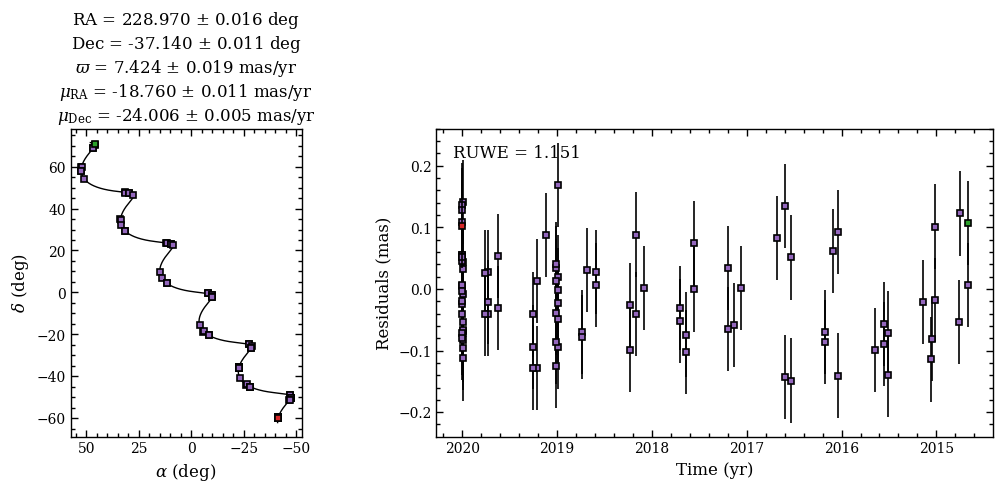

In [10]:
results = leastsq.singl_5param(plot_file='res_5param.png')

## Accelerating star

We will now simulate epoch astrometry for a 20 $M_\mathrm{J}$ companion on a 5 au orbit that will cause an acceleration of the stellar proper motion. 

In [11]:
mass_1 = primary_mass[0]  # (Msun)
mass_2 = 0.02  # (Msun)

In [12]:
sma, ecc, inc, aop, pan, tau = 7., 0.0, np.radians(45.0), np.radians(60.0), np.radians(90.0), 0.2

In [13]:
model_param = epoch_astrom.simulate_data(mass_1=mass_1, mass_2=mass_2,
                                         sma=sma, ecc=ecc, inc=inc, aop=aop, pan=pan, tau=tau,
                                         sigma_per_ccd=None, csv_out=None,
                                         ra=None, dec=None, parallax=None, pmra=None, pmdec=None, phot_g_mean_mag=None)


-------------
Simulate data
-------------

System type: binary

AL scan uncertainty (per CCD) = 193.14 uas
AL scan uncertainty (per transit) = 68.29 uas

Stellar parameters:
   - RA (deg) = 228.95
   - Dec (deg) = -37.15
   - Parallax (mas) = 7.41
   - Proper motion in RA (mas/yr) = -18.74
   - Proper motion in Dec (mas/yr) = -24.01
   - G-band magnitude = 7.75

Orbit parameters:
   - Primary mass (Msun) = 2.20
   - Secondary mass (Msun) = 0.02
   - Semi-major axis (au) = 7.00
   - Eccentricity = 0.00
   - Inclination (deg) = 45.00
   - Argument of periastron (deg) = 60.00
   - PA of ascending node (deg) = 90.00
   - Relative time of periastron = 0.20


Let's first plot the stellar orbit in comparison with the simulated 1D epoch astrometry.

In [14]:
bin_model = BinaryModel(epoch_astrometry=epoch_astrom)


----------------------
Calculate binary model
----------------------

Stellar parameters:
   - RA (deg) = 228.95
   - Dec (deg) = -37.15
   - Parallax (mas) = 7.41
   - Proper motion in RA (mas/yr) = -18.74
   - Proper motion in Dec (mas/yr) = -24.01

Orbit parameters:
   - Primary mass (Msun) = 2.20
   - Secondary mass (Msun) = 0.02
   - Semi-major axis (au) = 7.00
   - Eccentricity = 0.00
   - Inclination (deg) = 45.00
   - Argument of periastron (deg) = 60.00
   - PA of ascending node (deg) = 90.00
   - Relative time of periastron = 0.20

-------------------
Calculate residuals
-------------------

Reduced chi^2 = 1.35
RUWE = 1.16

----------
Plot orbit
----------



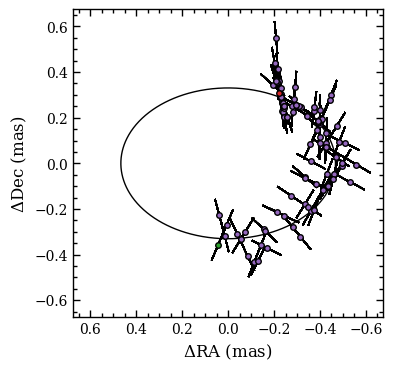

In [15]:
fig = bin_model.plot_orbit(model_param=model_param, plot_file=None)

We can now fit the epoch astrometry with a 5-parameter model (i.e. a single star).

In [16]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)


--------------------------
Single star (5-parameters)
--------------------------

Reduced chi^2 = 1.661
RUWE = 1.289
Inflation factor = 1.293

Best-fit parameters:
   - RA = 228.624 deg +/- 0.018 mas
   - Dec = -37.163 deg +/- 0.013 mas
   - Parallax = 7.395 +/- 0.021 mas
   - mu in RA = -18.787 +/- 0.012 mas/yr
   - mu in Dec = -23.867 +/- 0.006 mas/yr


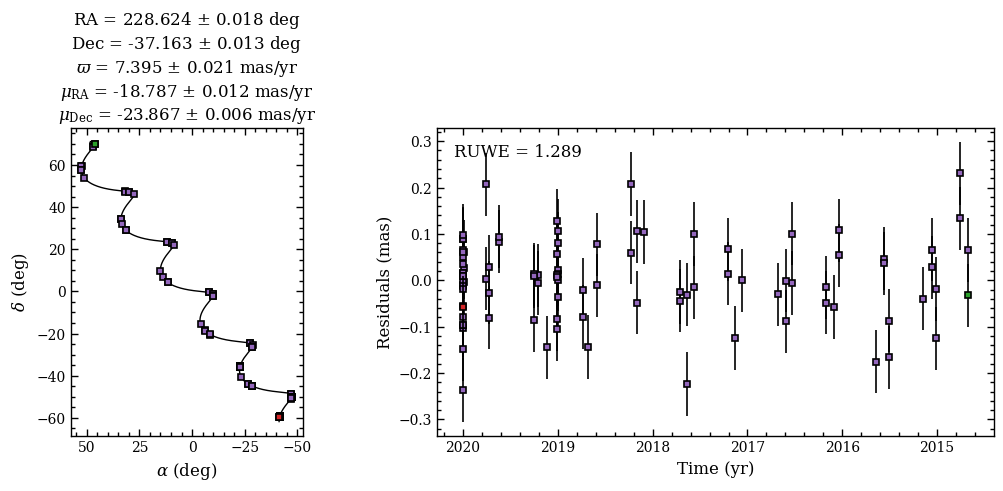

In [17]:
results = leastsq.singl_5param(plot_file='res_5param.png')

The RUWE from the single star model is 1.3, which warrants including an acceleration term.


--------------------------
Binary star (7-parameters)
--------------------------

Reduced chi^2 = 1.242
RUWE = 1.115
Inflation factor = 1.119

Best-fit parameters:
   - RA = 228.529 deg +/- 0.024 mas
   - Dec = -37.192 deg +/- 0.018 mas
   - Parallax = 7.391 +/- 0.018 mas
   - mu in RA = -18.788 +/- 0.011 mas/yr
   - mu in Dec = -23.876 +/- 0.006 mas/yr
   - dmu/dt in RA (mas/yr^2) = 0.080 +/- 0.016
   - dmu/dt in Dec (mas/yr^2) = 0.013 +/- 0.008


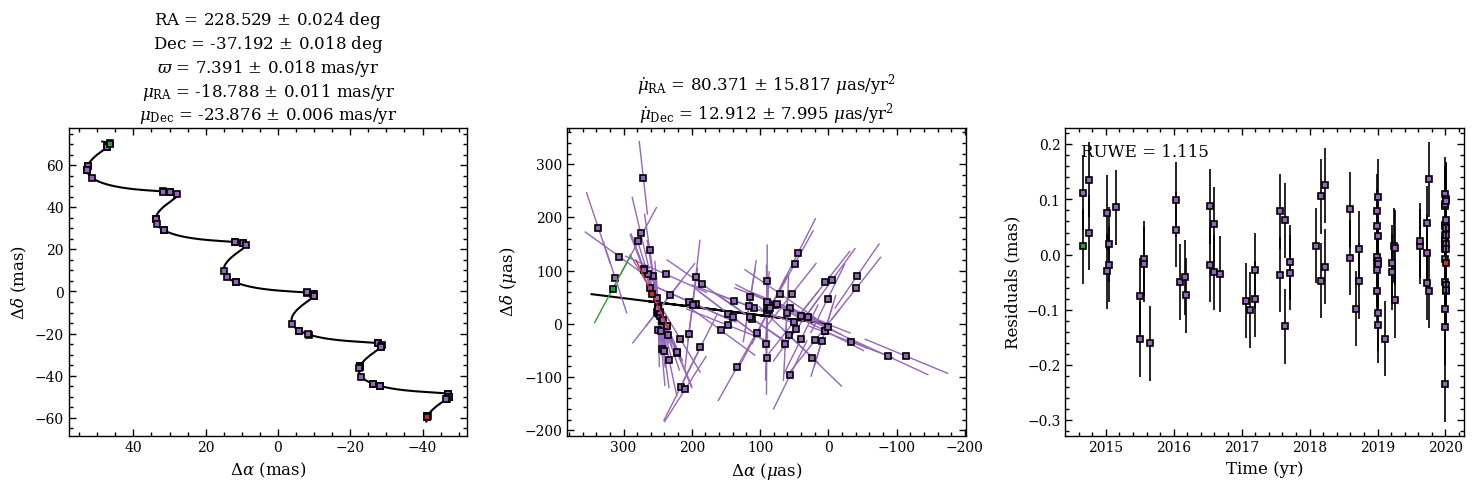

In [18]:
results = leastsq.accel_7param(plot_file='res_7param.png')

The RUWE became 1.05 by including the acceleration. Let's check if the data also warrants including the acceleration derivative, that is, the second-order derivative of the stellar proper motion.


--------------------------
Binary star (9-parameters)
--------------------------

Reduced chi^2 = 1.209
RUWE = 1.100
Inflation factor = 1.104

Best-fit parameters:
   - RA = 228.526 deg +/- 0.024 mas
   - Dec = -37.201 deg +/- 0.019 mas
   - Parallax = 7.395 +/- 0.018 mas
   - mu in RA = -18.814 +/- 0.026 mas/yr
   - mu in Dec = -23.848 +/- 0.016 mas/yr
   - dmu/dt in RA (mas/yr^2) = 0.090 +/- 0.016
   - dmu/dt in Dec (mas/yr^2) = 0.013 +/- 0.008
   - d^2mu/d^2t in RA (mas/yr^3) = 0.040 +/- 0.035
   - d^2mu/d^2t in Dec (mas/yr^3) = -0.032 +/- 0.017


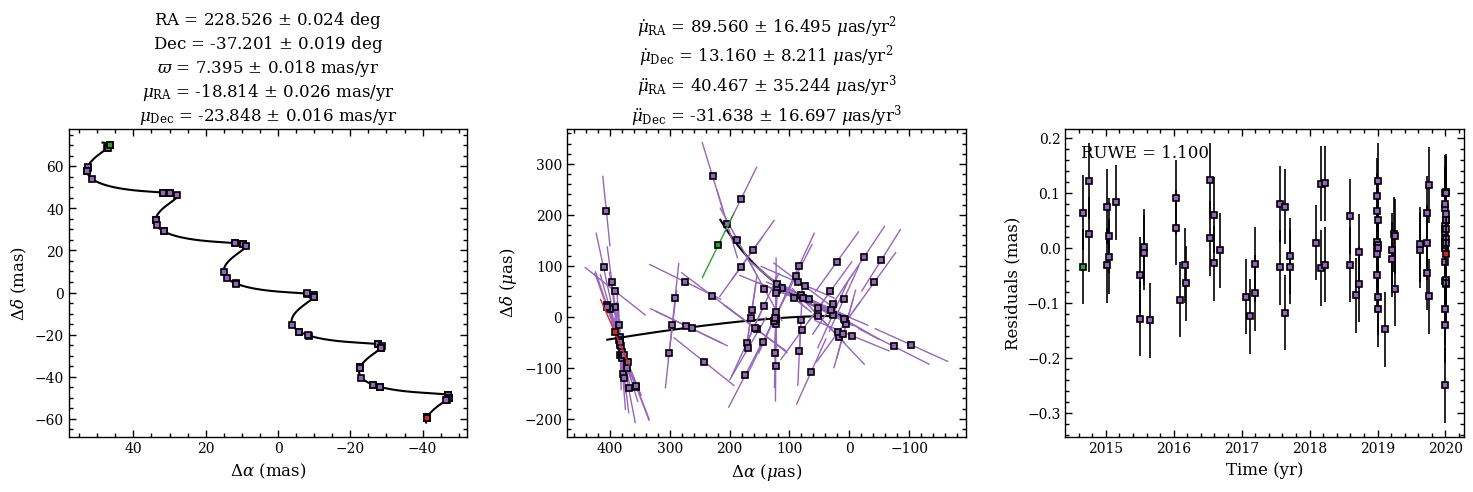

In [19]:
results = leastsq.accel_9param(plot_file='res_9param.png')

Indeed, as expected from the previous RUWE, the data does not warant including the derivative of the acceleration, since the derivative is not constrained and the RUWE has the same value as the 7-parameter fit.

# Binary system

Now we simulate again a binary system, but with a smaller companion orbit such that most of the orbital phase is sampled by the simulated Gaia DR4 measurements.

In [20]:
sma = 3.0  # (au)

In [21]:
model_param = epoch_astrom.simulate_data(mass_1=mass_1, mass_2=mass_2,
                                         sma=sma, ecc=ecc, inc=inc, aop=aop, pan=pan, tau=tau,
                                         sigma_per_ccd=None, csv_out=None,
                                         ra=None, dec=None, parallax=None, pmra=None, pmdec=None, phot_g_mean_mag=None)


-------------
Simulate data
-------------

System type: binary

AL scan uncertainty (per CCD) = 193.14 uas
AL scan uncertainty (per transit) = 68.29 uas

Stellar parameters:
   - RA (deg) = 228.95
   - Dec (deg) = -37.15
   - Parallax (mas) = 7.41
   - Proper motion in RA (mas/yr) = -18.74
   - Proper motion in Dec (mas/yr) = -24.01
   - G-band magnitude = 7.75

Orbit parameters:
   - Primary mass (Msun) = 2.20
   - Secondary mass (Msun) = 0.02
   - Semi-major axis (au) = 3.00
   - Eccentricity = 0.00
   - Inclination (deg) = 45.00
   - Argument of periastron (deg) = 60.00
   - PA of ascending node (deg) = 90.00
   - Relative time of periastron = 0.20


In [22]:
bin_model = BinaryModel(epoch_astrometry=epoch_astrom)


----------------------
Calculate binary model
----------------------

Stellar parameters:
   - RA (deg) = 228.95
   - Dec (deg) = -37.15
   - Parallax (mas) = 7.41
   - Proper motion in RA (mas/yr) = -18.74
   - Proper motion in Dec (mas/yr) = -24.01

Orbit parameters:
   - Primary mass (Msun) = 2.20
   - Secondary mass (Msun) = 0.02
   - Semi-major axis (au) = 3.00
   - Eccentricity = 0.00
   - Inclination (deg) = 45.00
   - Argument of periastron (deg) = 60.00
   - PA of ascending node (deg) = 90.00
   - Relative time of periastron = 0.20

-------------------
Calculate residuals
-------------------

Reduced chi^2 = 1.02
RUWE = 1.01

----------
Plot orbit
----------



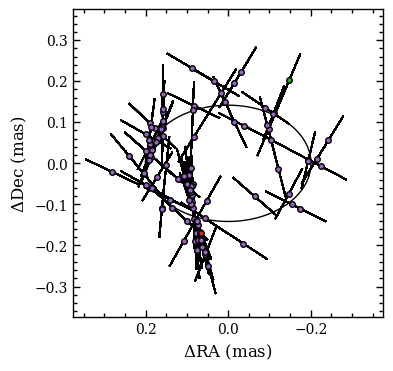

In [23]:
fig = bin_model.plot_orbit(model_param=model_param, plot_file=None)

In [24]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)


---------------------
Orbit (12-parameters)
---------------------



  0%|          | 0/125000 [00:00<?, ?it/s]

Best-fit parameters (RUWE = 0.926):
   - RA = 228.957 deg +/- 0.015 mas
   - Dec = -37.139 deg +/- 0.011 mas
   - Parallax = 7.400 +/- 0.017 mas
   - mu in RA = -18.729 +/- 0.010 mas/yr
   - mu in Dec = -24.001 +/- 0.006 mas/yr
   - Thiele-Innes B = -0.201 +/- 0.021
   - Thiele-Innes G = -0.010 +/- 0.021
   - Thiele-Innes A = -0.017 +/- 0.016
   - Thiele-Innes F = 0.146 +/- 0.015
   - Semi-major axis = 2.924 au
   - Eccentricity = 0.020
   - Relative time of periastron = 0.00


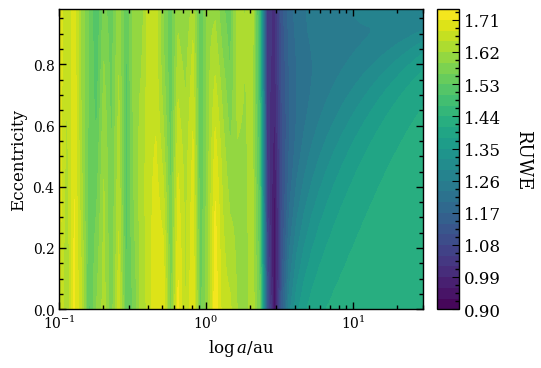

In [25]:
fig = leastsq.orbit_grid(plot_file='ruwe_orbit.png')

In [26]:
sampler = MCMCSampler(epoch_astrometry=epoch_astrom)
# sampler = NestedSampler(epoch_astrometry=epoch_astrom)


--------------------------
Single star (5-parameters)
--------------------------

Reduced chi^2 = 2.992
RUWE = 1.730
Inflation factor = 1.736

Best-fit parameters:
   - RA = 228.976 deg +/- 0.025 mas
   - Dec = -37.121 deg +/- 0.017 mas
   - Parallax = 7.382 +/- 0.029 mas
   - mu in RA = -18.733 +/- 0.016 mas/yr
   - mu in Dec = -24.042 +/- 0.008 mas/yr

--------------------------
Binary star (7-parameters)
--------------------------

Reduced chi^2 = 2.867
RUWE = 1.693
Inflation factor = 1.699

Best-fit parameters:
   - RA = 228.953 deg +/- 0.037 mas
   - Dec = -37.069 deg +/- 0.028 mas
   - Parallax = 7.388 +/- 0.028 mas
   - mu in RA = -18.723 +/- 0.017 mas/yr
   - mu in Dec = -24.042 +/- 0.008 mas/yr
   - dmu/dt in RA (mas/yr^2) = 0.024 +/- 0.024
   - dmu/dt in Dec (mas/yr^2) = -0.029 +/- 0.012

--------------------------
Binary star (9-parameters)
--------------------------

Reduced chi^2 = 2.032
RUWE = 1.425
Inflation factor = 1.431

Best-fit parameters:
   - RA = 228.947 deg +/-

In [27]:
sampler.run_ptmcmc(
    pickle_file='exogaia.pkl',
    n_temps=10,
    n_walkers=100,
    n_steps=10000,
    n_sweeps=1,
    progress=False,
)

The chain is shorter than 50 times the integrated autocorrelation time for 13 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 200;
tau: [ 882.48589985  854.4297767   929.45217675  801.53626974  575.56855011
  614.18973416 1004.55169345  966.53672377  905.32341707  813.98949252
  867.95557204  863.77858883  850.33544452]
The chain is shorter than 50 times the integrated autocorrelation time for 13 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 200;
tau: [919.654043   858.03071156 803.84373334 940.85888797 713.16903851
 791.29966943 965.98147146 949.06732993 873.17094331 859.97585543
 909.73887019 974.97089902 834.62226381]
The chain is shorter than 50 times the integrated autocorrelation time for 13 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 200;
tau: [ 910.46596681  929.30998721  886.83077535  815.97252388  844.50491983
  813.83322405 1032.77923069 1030.45419402  990.50925967  921.51096431
  954.0

## Plot results from orbit fit

In [28]:
results = FitResults(burnin=5000, pickle_file='exogaia.pkl')


-----------
Fit results
-----------

Number of parameters: 13
Samples shape: (10, 10000, 100, 13)

Burnin: 5000
Samples shape: (10, 5000, 100, 13)

Reshaped samples: (5000000, 13)



------------
Plot walkers
------------

Number of walkers: 100
Thin value: 1


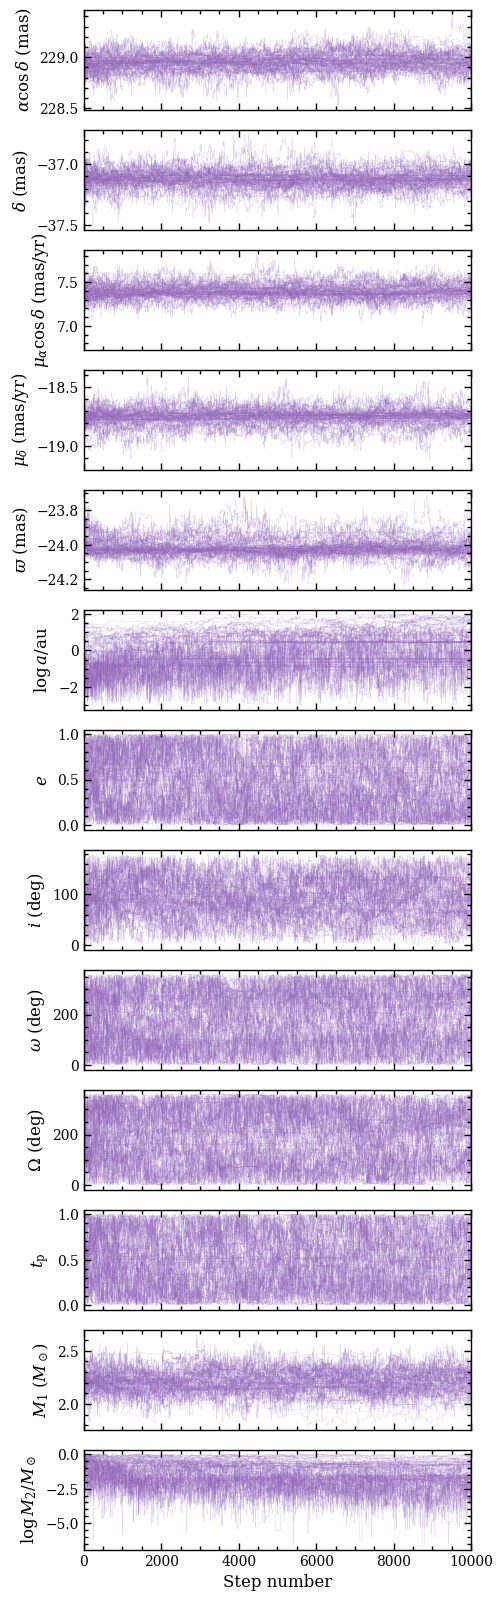

In [29]:
fig = results.plot_walkers(n_walkers=100, thin=None, plot_file=None)


--------------
Plot posterior
--------------



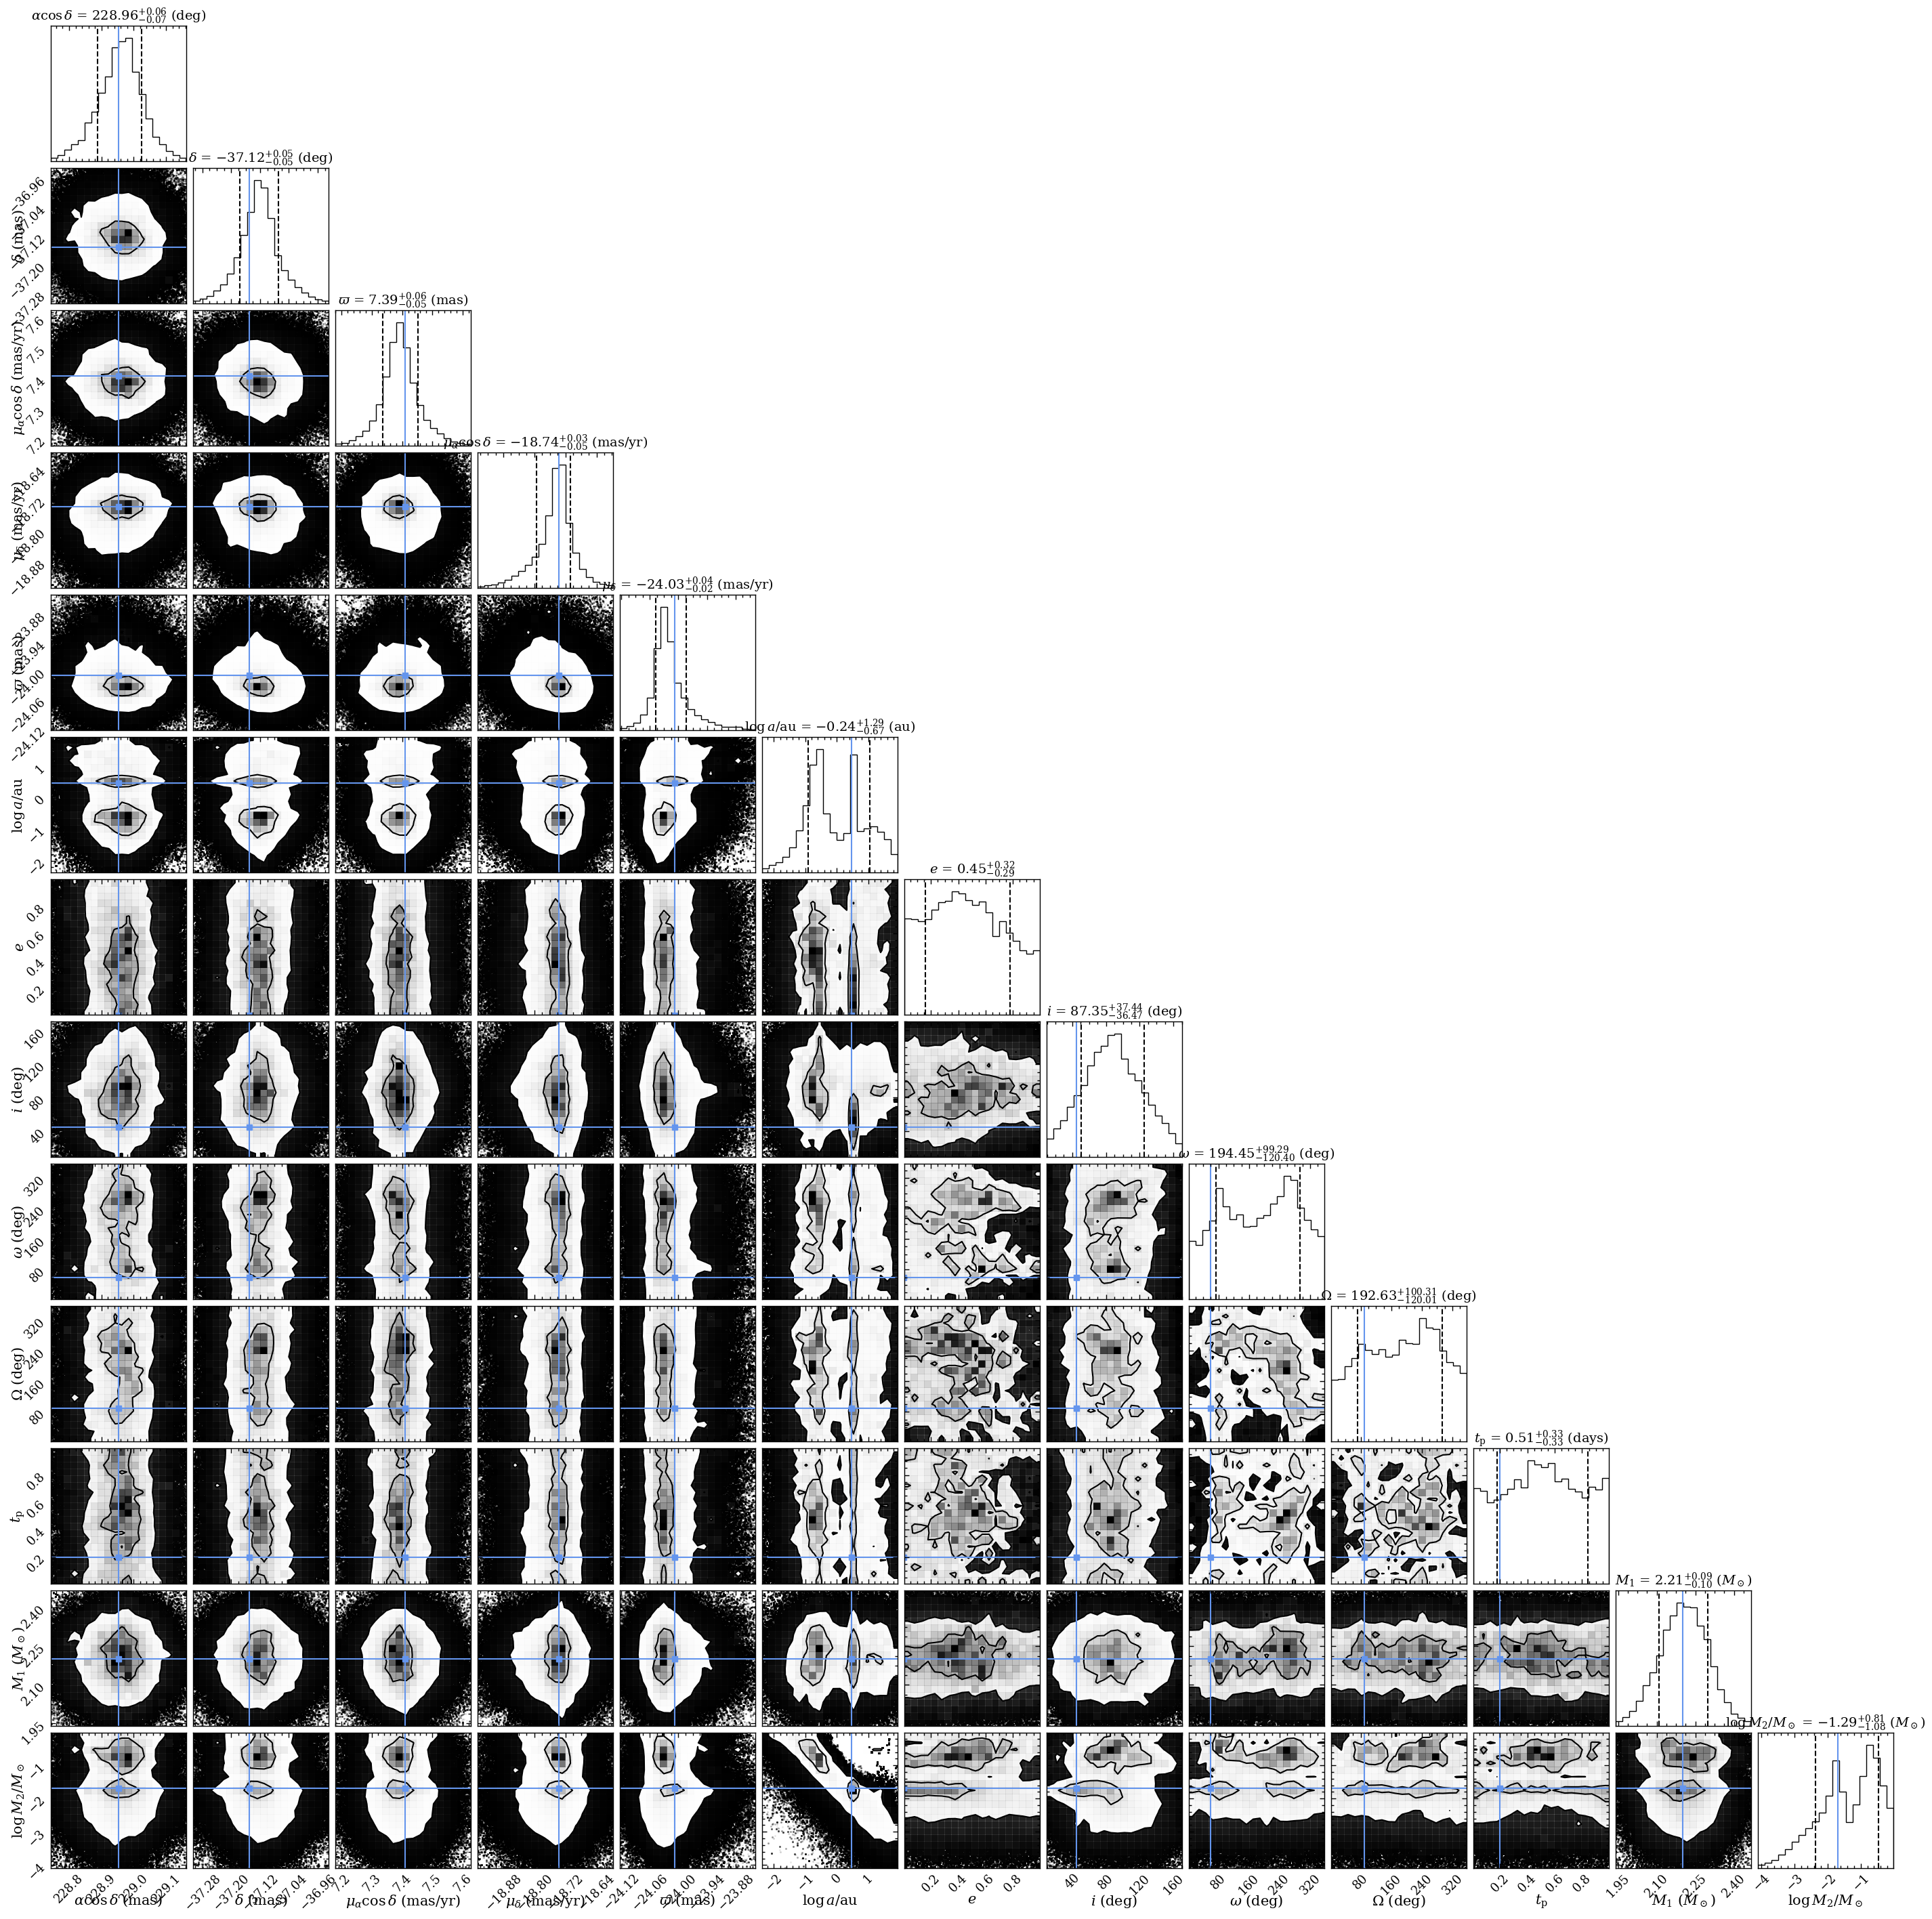

In [30]:
fig = results.plot_posterior(truths=model_param, plot_file=None)


--------------
Plot residuals
--------------


----------------------
Calculate binary model
----------------------

Stellar parameters:
   - RA (deg) = 229.00
   - Dec (deg) = -37.15
   - Parallax (mas) = 7.39
   - Proper motion in RA (mas/yr) = -18.73
   - Proper motion in Dec (mas/yr) = -24.00

Orbit parameters:
   - Primary mass (Msun) = 2.24
   - Secondary mass (Msun) = 0.02
   - Semi-major axis (au) = 2.86
   - Eccentricity = 0.12
   - Inclination (deg) = 41.37
   - Argument of periastron (deg) = 51.10
   - PA of ascending node (deg) = 277.81
   - Relative time of periastron = 0.68


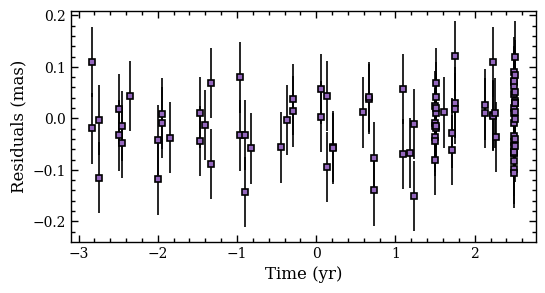

In [31]:
fig = results.plot_residuals(plot_file=None)


----------
Plot orbit
----------



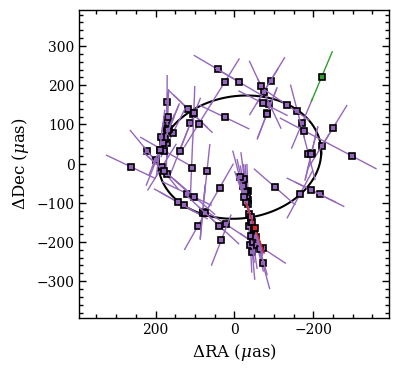

In [32]:
fig = results.plot_orbit(plot_file=None)